# Phase 2 — Data Visualization

**Goal:** Build intuition about the star dataset through plots. Reproduce the classic Hertzsprung–Russell (HR) diagram and explore feature relationships.

**Libraries:** `pandas`, `matplotlib`, `seaborn`

**Input:** `../star_dataset_clean.csv` (produced in Phase 1)

**Output:** Saved figures in a `../figures/` folder

In [10]:
# --- Imports ---
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
# --- Load Data ---
# Load star_dataset_clean.csv into a pandas DataFrame
# Print the first few rows and column names to confirm it loaded correctly

df = pd.read_csv("../star_dataset_clean.csv")
df.info()
print(df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               29 non-null     str    
 1   Distance (ly)      29 non-null     float64
 2   Luminosity (L/Lo)  29 non-null     float64
 3   Radius (R/Ro)      29 non-null     float64
 4   Temperature (K)    29 non-null     float64
 5   Spectral Class     29 non-null     str    
dtypes: float64(4), str(2)
memory usage: 1.5 KB
               Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  \
0          Achernar     144.078936        3149.761447       9.209602   
1             Acrux     320.916707       25000.665022       8.391405   
2         Aldebaran      65.028559         517.761826      44.179148   
3           Alnilam    2000.090906       53699.999016      32.395467   
4  Alpha Centauri B       4.360539           3.221930       0.885471   

   Temperature (K) Spectral Class  
0     15

In [12]:
# --- Setup: Output Folder ---
# Create a '../figures/' directory if it doesn't already exist
# Use os.makedirs with exist_ok=True so it won't error if it already exists
output_folder = "../figures/"
os.makedirs(output_folder, exist_ok=True)

C:\Users\ajgeb\AppData\Local\Temp\ipykernel_30912\4073140770.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 7)


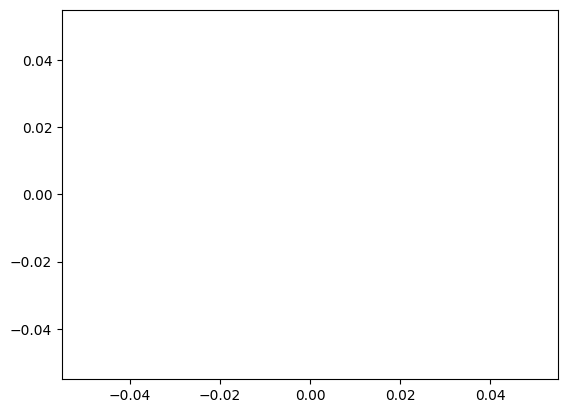

In [13]:
# --- Plot 1: Hertzsprung-Russell (HR) Diagram ---
# The HR diagram is one of the most important plots in astronomy.
# It reveals stellar evolution patterns (main sequence, giants, dwarfs).
#
# X-axis: Temperature (K) — INVERTED (hot stars on the left, cool on the right)
# Y-axis: Luminosity (L/Lo) — log scale
# Color each point by its Spectral Class
#
# Steps:
#   1. Create a color map: assign a unique color to each spectral class (O, B, A, F, G, K, M)
#   2. Use plt.scatter() — set x=Temperature, y=Luminosity
#   3. Set yscale to 'log'
#   4. Invert the x-axis with ax.invert_xaxis()
#   5. Add axis labels, a title, and a legend for spectral classes
#   6. Save the figure to '../figures/hr_diagram.png'

cmap = plt.cm.get_cmap('tab10', 7)
color = cmap(0)

classes = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
colors = plt.cm.tab10.colors
color_map = { cls: colors[i] for i, cls in enumerate(classes) }

for cls in classes:
  mask = df['Spectral Class'] == cls
  plt.scatter(df[mask]['Temperature (K)'], df[mask]['Luminosity (L/Lo)'],
              color=color_map[cls], label=cls)

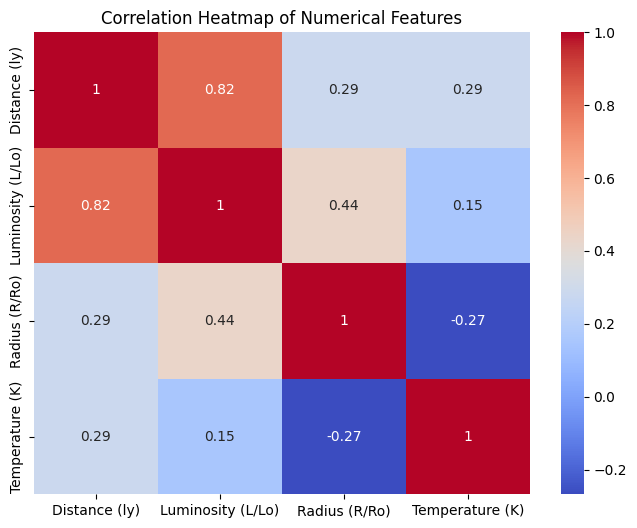

In [14]:
# --- Plot 2: Correlation Heatmap ---
# Shows how strongly numerical features are related to each other.
#
# Steps:
#   1. Select only the four numerical columns: Distance, Luminosity, Radius, Temperature
#   2. Compute the correlation matrix with .corr()
#   3. Plot with sns.heatmap() — use annot=True to show values, cmap='coolwarm'
#   4. Add a title
#   5. Save to '../figures/correlation_heatmap.png'
numerical_cols = ['Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)']
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig(os.path.join(output_folder, 'correlation_heatmap.png'))

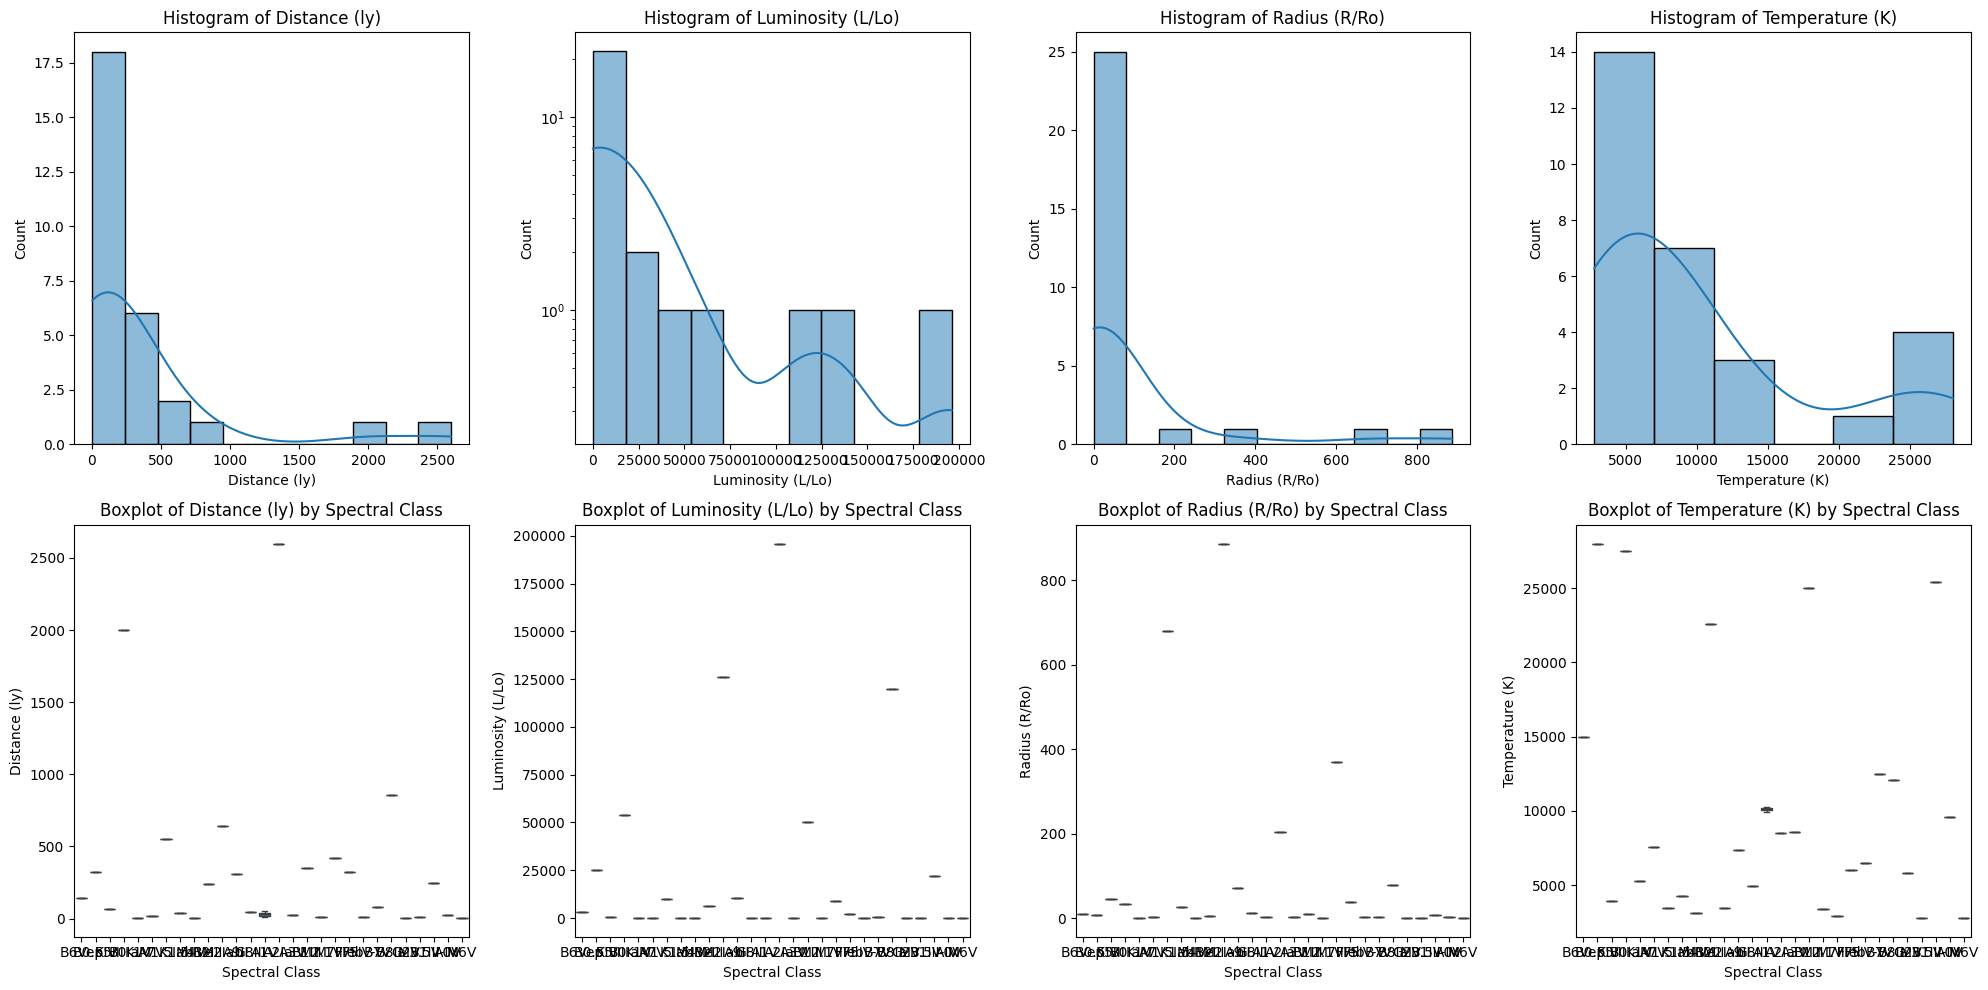

In [17]:
# --- Plot 3: Feature Distributions (Histograms + Boxplots) ---
# Understanding the shape of each feature reveals skew, outliers, and scale differences.
#
# Steps:
#   1. Create a figure with 2 rows and 4 columns of subplots (one per numerical feature)
#   2. Top row: histogram for each feature (use log scale for luminosity)
#   3. Bottom row: boxplot for each feature grouped by Spectral Class
#   4. Save to '../figures/feature_distributions.png'

numerical_cols = ['Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(numerical_cols):
    # Histogram
    sns.histplot(df[col], ax=axes[0, i], kde=True)
    axes[0, i].set_title(f'Histogram of {col}')
    if col == 'Luminosity (L/Lo)':
        axes[0, i].set_yscale('log')
    
    # Boxplot by Spectral Class
    sns.boxplot(x='Spectral Class', y=col, data=df, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot of {col} by Spectral Class')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'feature_distributions.png'))

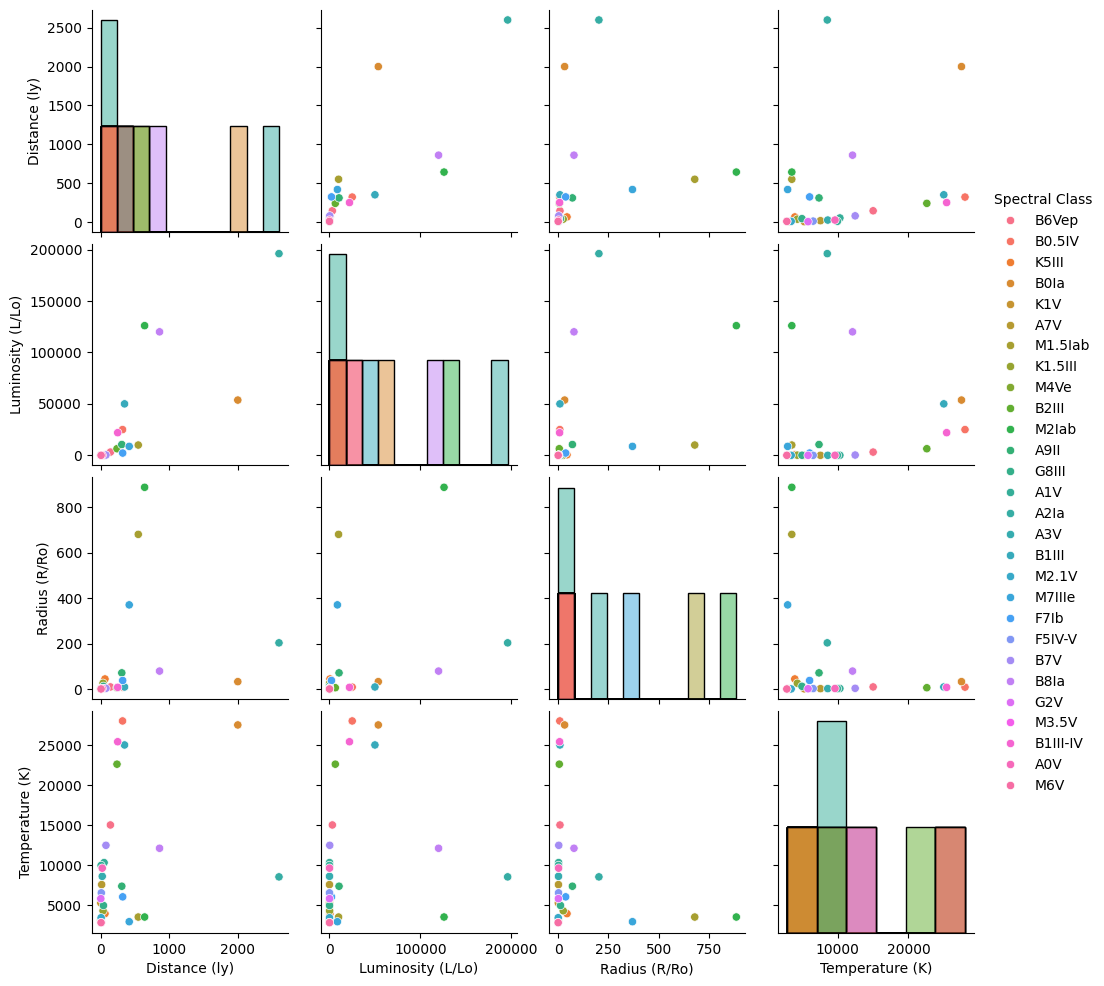

In [18]:
# --- Plot 4: Pairplot ---
# Plots every feature against every other feature — useful for spotting clusters.
#
# Steps:
#   1. Use sns.pairplot() on the four numerical columns
#   2. Set hue='Spectral Class' so points are colored by class
#   3. Set diag_kind='hist' or 'kde' for the diagonal cells
#   4. Save to '../figures/pairplot.png'
#
# Note: pairplot returns a PairGrid — call .savefig() on it, not plt.savefig()
pairplot = sns.pairplot(df[numerical_cols + ['Spectral Class']], hue='Spectral Class', diag_kind='hist')
pairplot.savefig(os.path.join(output_folder, 'pairplot.png'))